<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


#### Install the required libraries and import them


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sqlite3
import os

# 1. Ścieżka do Twojego pliku CSV
csv_path = '/Users/michalbando/Downloads/Różne/IT/Python/data/survey_data_newest.csv'
db_name = 'local_survey.db'

# 2. Usuwamy starą bazę, jeśli istnieje, żeby zacząć "na czysto"
if os.path.exists(db_name):
    os.remove(db_name)

# 3. Wczytujemy plik CSV do Pandas
df = pd.read_csv(csv_path)

# 4. Tworzymy połączenie sqlite3 i zapisujemy DataFrame jako tabelę 'main'
# To stworzy PRAWIDŁOWY plik bazy danych .db
conn = sqlite3.connect(db_name)
df.to_sql('main', conn, index=False, if_exists='replace')

# 5. Konfiguracja magii SQL
%load_ext sql
%config SqlMagic.style = '_DEPRECATED_DEFAULT' # Naprawa błędu KeyError: 'DEFAULT'
%sql sqlite:///local_survey.db

print(f"Sukces! Wczytano {len(df)} wierszy do tabeli 'main' w bazie {db_name}.")

The sql extension is already loaded. To reload it, use:
  %reload_ext sql
Sukces! Wczytano 65437 wierszy do tabeli 'main' w bazie local_survey.db.


#### Connect to the SQLite database


## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [29]:
%%sql

SELECT * FROM main LIMIT 2;

 * sqlite:///local_survey.db
   sqlite:///survey-data.sqlite
Done.


ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,YearsCode,YearsCodePro,DevType,OrgSize,PurchaseInfluence,BuyNewTool,BuildvsBuy,TechEndorse,Country,Currency,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,WebframeHaveWorkedWith,WebframeWantToWorkWith,WebframeAdmired,EmbeddedHaveWorkedWith,EmbeddedWantToWorkWith,EmbeddedAdmired,MiscTechHaveWorkedWith,MiscTechWantToWorkWith,MiscTechAdmired,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,ToolsTechAdmired,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,NEWCollabToolsAdmired,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,OfficeStackSyncHaveWorkedWith,OfficeStackSyncWantToWorkWith,OfficeStackSyncAdmired,AISearchDevHaveWorkedWith,AISearchDevWantToWorkWith,AISearchDevAdmired,NEWSOSites,SOVisitFreq,SOAccount,SOPartFreq,SOHow,SOComm,AISelect,AISent,AIBen,AIAcc,AIComplex,AIToolCurrently Using,AIToolInterested in Using,AIToolNot interested in Using,AINextMuch more integrated,AINextNo change,AINextMore integrated,AINextLess integrated,AINextMuch less integrated,AIThreat,AIEthics,AIChallenges,TBranch,ICorPM,WorkExp,Knowledge_1,Knowledge_2,Knowledge_3,Knowledge_4,Knowledge_5,Knowledge_6,Knowledge_7,Knowledge_8,Knowledge_9,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,None,None,None,None,None,None,None,None,None,None,United States of America,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,I have never visited Stack Overflow or the Stack Exchange network,None,None,None,None,None,Yes,Very favorable,Increase productivity,None,None,None,None,None,None,None,None,None,None,None,None,None,No,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other (please specify):,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Books / Physical media;Colleague;On the job training;Other online resources (e.g., videos, blogs, forum, online community)",Technical documentation;Blogs;Books;Written Tutorials;Stack Overflow,API document(s) and/or SDK document(s);User guides or README files found in the source repository;First-party knowledge base;Traditional public search engine,20,17,"Developer, full-stack",None,None,None,None,None,United Kingdom of Great Britain and Northern Ireland,None,None,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaScript;Python;TypeScript,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaScript;Kotlin;Python;TypeScript,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaScript;Python;TypeScript,Dynamodb;MongoDB;PostgreSQL,PostgreSQL,PostgreSQL,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Express;Next.js;Node.js;React,Express;Htmx;Node.js;React;Remix,Express;Node.js;React,None,None,None,None,None,None,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,MacOS;Win

In [30]:
QUERY = "SELECT * FROM main LIMIT 5"
df = pd.read_sql_query(QUERY, conn)
df

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,None,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,None,None
3,4,I am learning to code,18-24 years old,"Student, full-time",None,Apples,None,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,None,None
4,5,I am a developer by profession,18-24 years old,"Student, full-time",None,Apples,None,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,None,None


In [31]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [32]:
QUERY = """
SELECT name as Table_Name
FROM sqlite_master
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [33]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


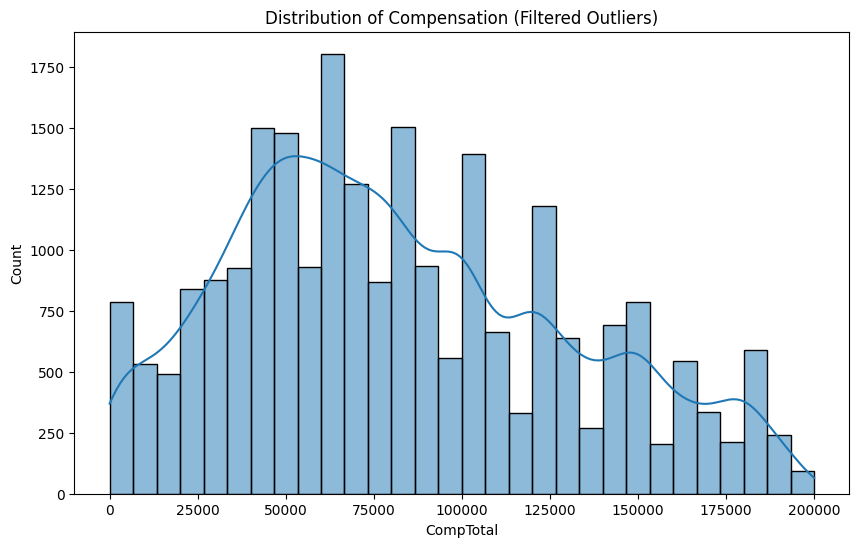

In [34]:
# 1. Pobieramy dane z bazy, odcinając nierealne wartości (outliery)
query = "SELECT CompTotal FROM main WHERE CompTotal < 200000"
df_comp = pd.read_sql_query(query, conn)

plt.figure(figsize=(10,6))
sns.histplot(df_comp['CompTotal'], bins=30, kde=True)
plt.title('Distribution of Compensation (Filtered Outliers)')
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


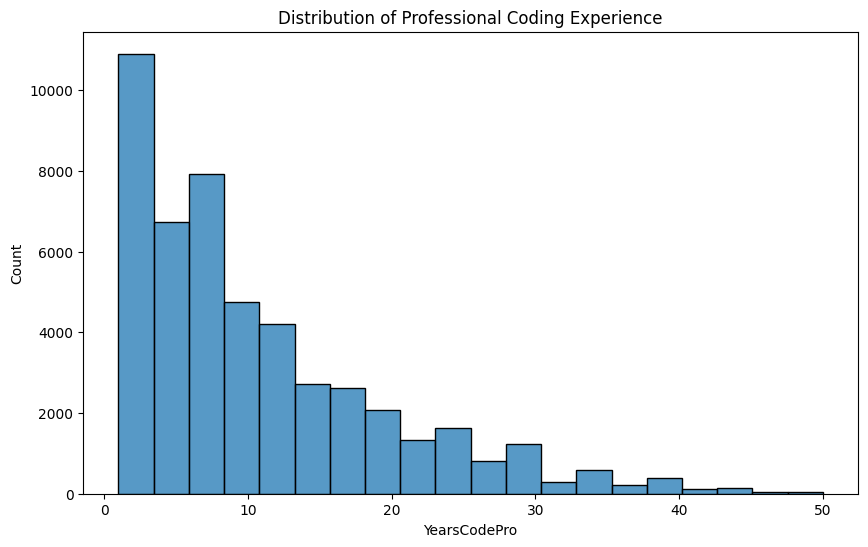

In [35]:
# 1. Pobieramy dane
query = "SELECT YearsCodePro FROM main"
df_code = pd.read_sql_query(query, conn)

# 2. YearsCodePro często zawiera tekst 'Less than 1 year', więc czyścimy to w Pandas
df_code['YearsCodePro'] = pd.to_numeric(df_code['YearsCodePro'], errors='coerce')

# 3. Rysujemy
plt.figure(figsize=(10,6))
sns.histplot(df_code['YearsCodePro'].dropna(), bins=20)
plt.title('Distribution of Professional Coding Experience')
plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


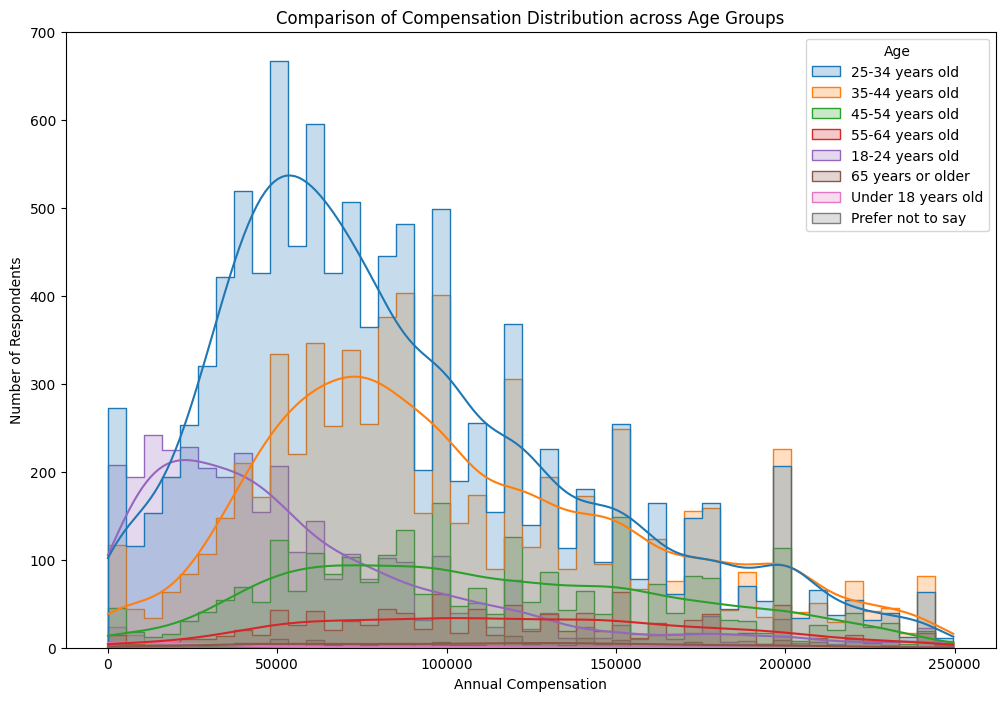

In [ ]:
# 1. Przygotowujemy zapytanie SQL
# Wybieramy surowe dane (bez GROUP BY), filtrując braki (IS NOT NULL)
# i usuwając outliery (np. zarobki powyżej 250,000)
query = """
SELECT Age, CompTotal
FROM main
WHERE CompTotal IS NOT NULL
  AND Age IS NOT NULL
  AND CompTotal < 250000
"""

# 2. Wczytujemy do DataFrame
df_dist = pd.read_sql_query(query, conn)

plt.figure(figsize=(12, 8))
# Parametr 'hue' odpowiada za porównanie rozkładów między grupami wieku
sns.histplot(data=df_dist, x='CompTotal', hue='Age', kde=True, element="step")

plt.title('Comparison of Compensation Distribution across Age Groups')
plt.xlabel('Annual Compensation')
plt.ylabel('Number of Respondents')
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


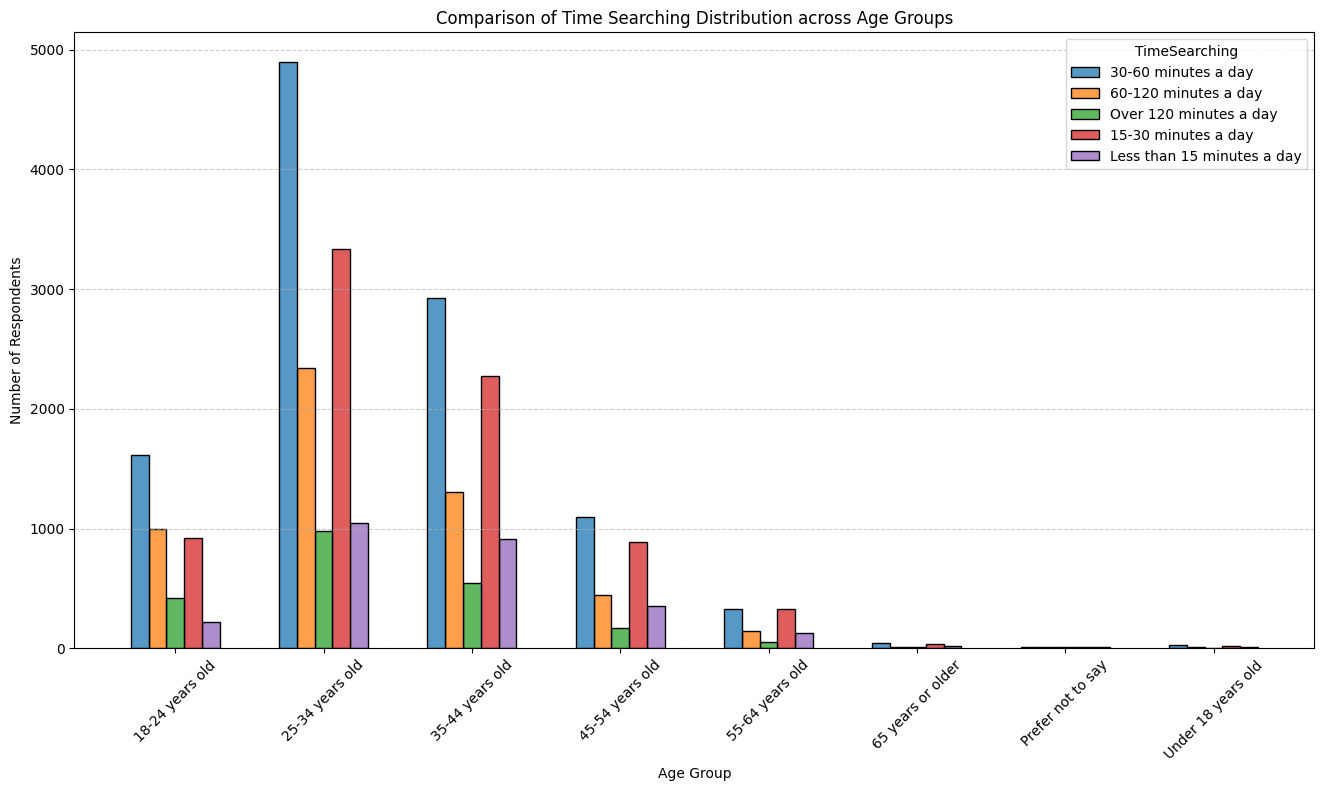

In [ ]:
query = """
SELECT Age, TimeSearching
FROM main
WHERE TimeSearching IS NOT NULL
  AND Age IS NOT NULL
  AND TimeSearching is not null
"""

df_dist = pd.read_sql_query(query, conn)

plt.figure(figsize=(16, 8))

sns.histplot(
    data=df_dist.sort_values('Age'),
    x='Age',
    hue='TimeSearching',
    multiple="dodge",
    shrink=.6
)

plt.title('Comparison of Time Searching Distribution across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6) # Dodatkowa siatka pomocnicza
plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


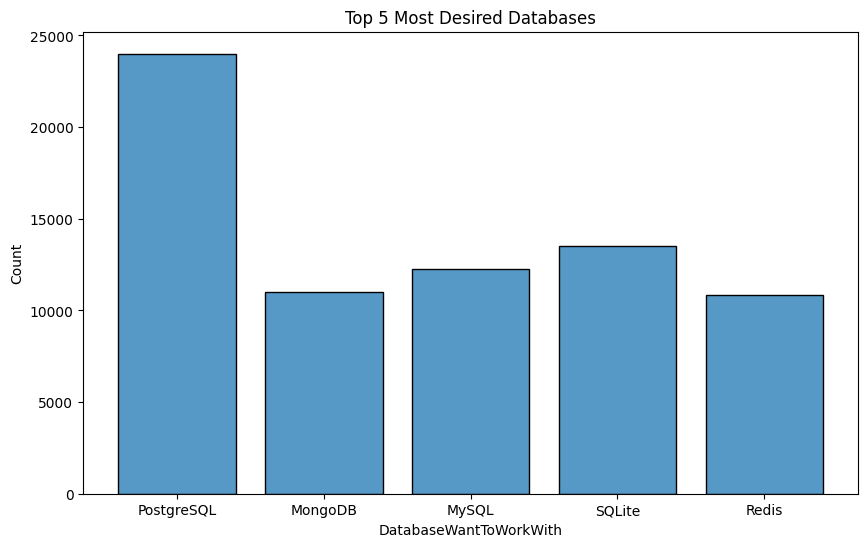

In [ ]:
# Pobieramy dane i robimy tylko explode() - bez liczenia
df_db = pd.read_sql_query("SELECT DatabaseWantToWorkWith FROM main", conn)
exploded_db = df_db['DatabaseWantToWorkWith'].str.split(';').explode()

# Wybieramy tylko te bazy, które są w top 5, żeby wykres był czytelny
top_5_names = exploded_db.value_counts().head(5).index
filtered_db = exploded_db[exploded_db.isin(top_5_names)]

plt.figure(figsize=(10,6))
# Podajemy tylko x, Seaborn sam policzy słupki od 0
sns.histplot(x=filtered_db, shrink=0.8)

plt.title('Top 5 Most Desired Databases')
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


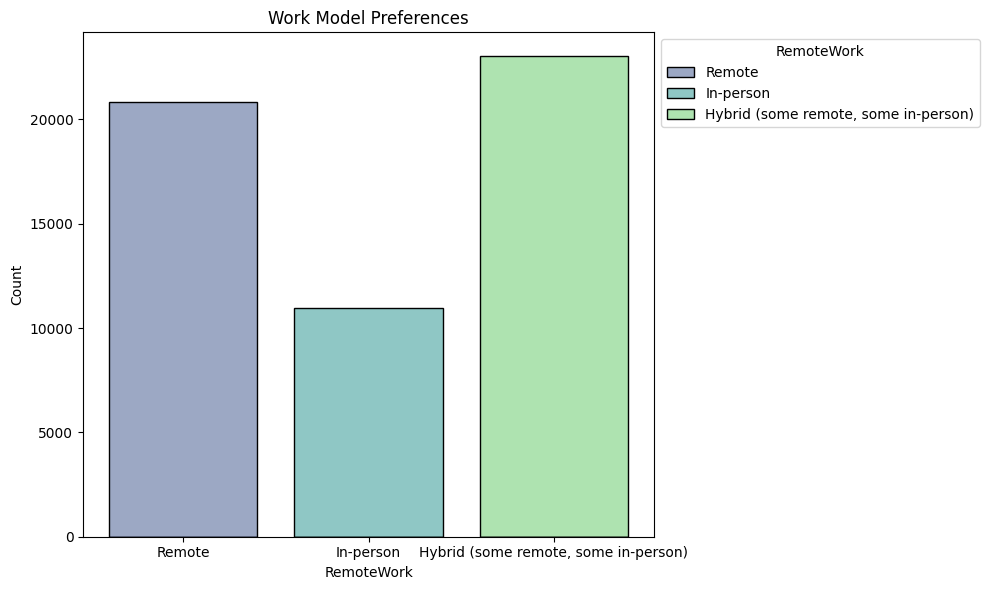

In [ ]:
df_db = pd.read_sql_query("SELECT RemoteWork FROM main", conn)
exploded_db1 = df_db['RemoteWork'].str.split(';').explode()

top_3_remote_works = exploded_db1.value_counts().head(5).index
filtered_db1 = exploded_db1[exploded_db1.isin(top_3_remote_works)]

plt.figure(figsize=(10,6))
ax = sns.histplot(x=filtered_db1, shrink=0.8, palette="viridis", hue=filtered_db1)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.title('Work Model Preferences')
plt.tight_layout()
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


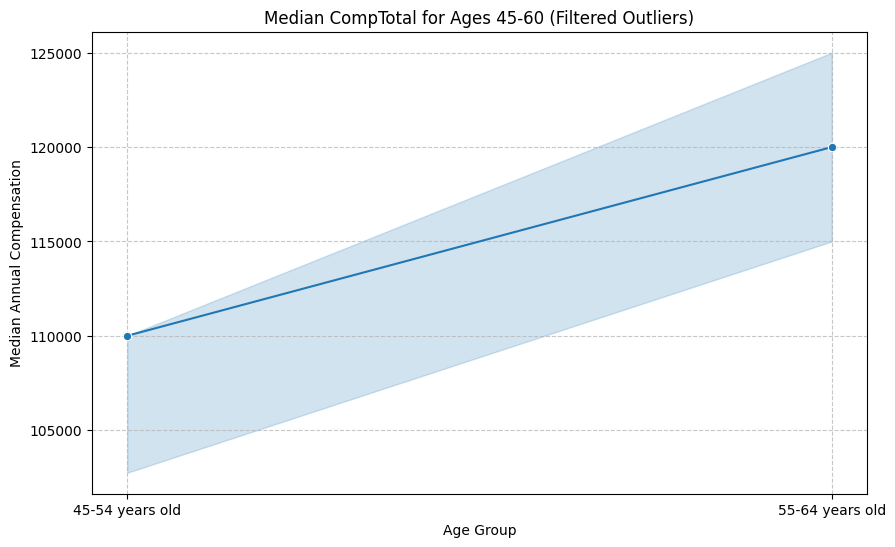

In [ ]:
# 1. Pobieramy dane z bazy dla grup wiekowych obejmujących zakres 45-60 lat
query = """
SELECT Age, CompTotal
FROM main
WHERE Age IN ('45-54 years old', '55-64 years old')
  AND CompTotal IS NOT NULL
"""
df_45_60 = pd.read_sql_query(query, conn)

# 2. Usuwamy ekstremalne błędy (outliery) - np. zarobki powyżej 300,000
# To zlikwiduje skalę 1e146 i sprawi, że wykres będzie czytelny
df_clean = df_45_60[df_45_60['CompTotal'] < 300000]

# 3. Rysujemy wykres liniowy
plt.figure(figsize=(10, 6))

# Kluczowe: używamy estimator='median', aby linia łączyła mediany, a nie średnie
sns.lineplot(data=df_clean, x='Age', y='CompTotal', estimator='median', marker='o')

plt.title('Median CompTotal for Ages 45-60 (Filtered Outliers)')
plt.ylabel('Median Annual Compensation')
plt.xlabel('Age Group')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


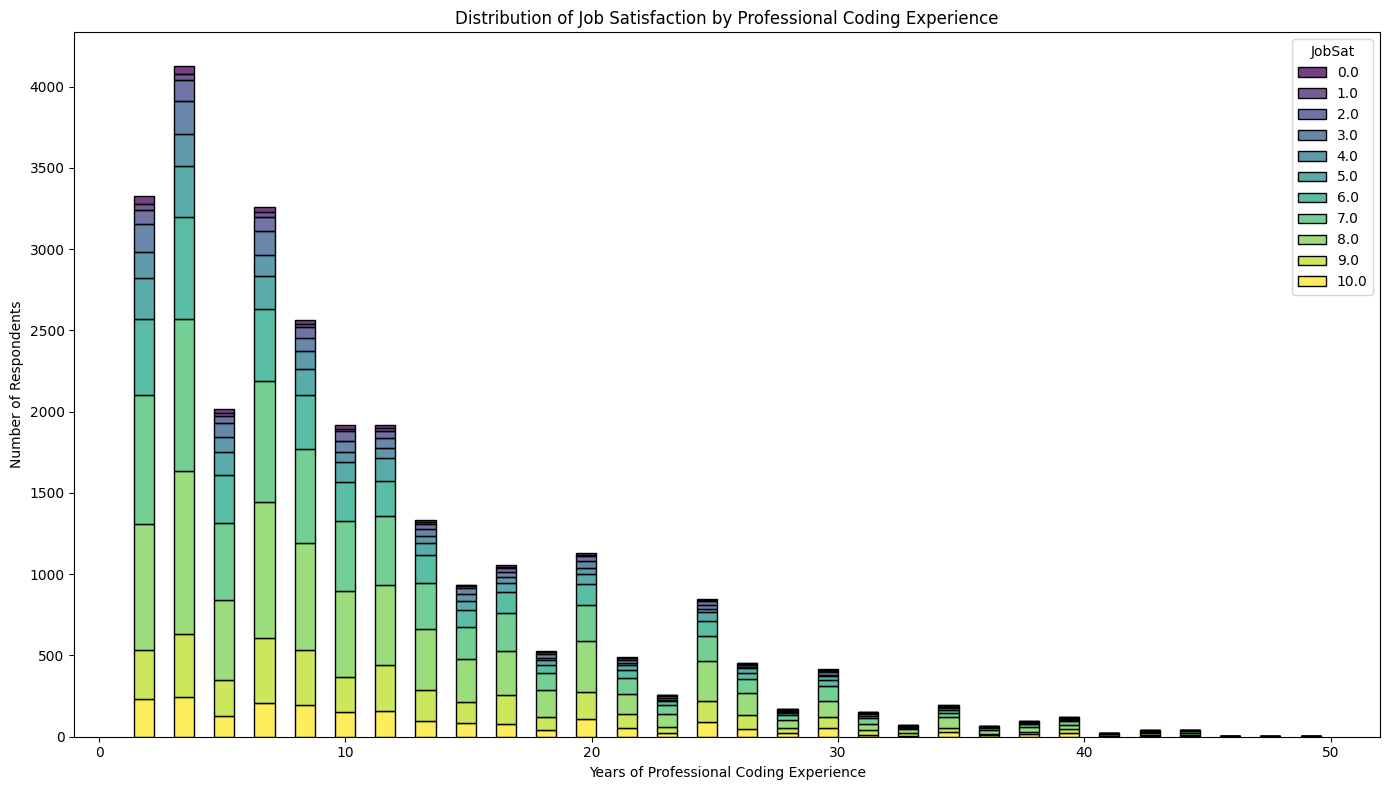

In [ ]:
# 1. Pobieramy dane o satysfakcji i latach doświadczenia z bazy
query = """
SELECT JobSat, YearsCodePro
FROM main
WHERE JobSat IS NOT NULL AND YearsCodePro IS NOT NULL
"""
df_jobsat = pd.read_sql_query(query, conn)

# 2. Czyszczenie danych: konwersja YearsCodePro na wartości liczbowe
# 'coerce' zamieni błędne wartości na NaN, które potem usuniemy
df_jobsat['YearsCodePro'] = pd.to_numeric(df_jobsat['YearsCodePro'], errors='coerce')
df_jobsat.dropna(subset=['YearsCodePro'], inplace=True)

# 3. Rysujemy histogram
plt.figure(figsize=(14, 8))

# Używamy multiple="stack", aby zobaczyć strukturę satysfakcji w każdym słupku doświadczenia
sns.histplot(
    data=df_jobsat,
    x='YearsCodePro',
    hue='JobSat',
    multiple="stack",
    shrink=0.5,
    bins=30,
    palette='viridis'
)

plt.title('Distribution of Job Satisfaction by Professional Coding Experience')
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Number of Respondents')

plt.tight_layout()
plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [118]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
